In [1]:
import numpy as np
import torch
from torch import linalg
import numpy as np
from scipy.stats import norm, uniform
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import bisect, brentq
from scipy.stats import Mixture, Normal, multivariate_normal, norm
from functools import partial
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

In [4]:

rng = np.random.default_rng(seed = 10404)
def cl(ndim, sigma = 1.0):
    A = rng.normal(0,sigma, size = (ndim,ndim))
    M = A @ A.T
    variances = np.diag(M)
    components = [Normal(mu=0, sigma = np.sqrt(v)) for v in variances]
    return M, Mixture(components)
mat, mix = cl(50)
def dialect_matrices(common_language, n_dialect, sigma=.01, mu_scale = .01):

    mat = []

    ndim = common_language.shape[0]

    for _ in range(n_dialect):
        mu = rng.normal(0, scale=mu_scale)
        P = rng.normal(mu, scale=sigma, size=(ndim, ndim))
        X = P @ P.T
        mat.append(X)
    return mat

  
def vector_sampling(common_language, dialect_matrices, n_samples=1000):
    n_dim = common_language.shape[0]
    K = len(dialect_matrices)
    d_stack = np.stack(dialect_matrices)  

    common_inds = rng.integers(0, n_dim, size=n_samples)
    mat_inds    = rng.integers(0, K,     size=n_samples)
    d_inds      = rng.integers(0, n_dim, size=n_samples)

    common_vectors    = common_language[common_inds]              
    dialect_vectors   = d_stack[mat_inds, d_inds]                 
    perturbed_vectors = common_vectors + dialect_vectors

    return common_vectors, perturbed_vectors

     
vs = vector_sampling(mat, dialect_matrices(mat, 30), n_samples = 1000)
print(vs)
d = dialect_matrices(mat, 30, sigma = .01, mu_scale = .01)
common_vectors, perturbed_vectors = vector_sampling(mat, d)



(array([[ -0.35891902, -12.98287534,   7.10962059, ..., -12.081747  ,
          1.82737685,  -1.43446985],
       [ -0.32524303,  -3.86992891,   4.51852243, ...,   2.12452896,
         -9.00432903,   0.73684471],
       [ -7.3582205 ,  -9.95008631,  -2.81437588, ...,   3.48417677,
         -3.46868927,  -0.54993502],
       ...,
       [ -2.00175828,   2.23309186,   5.47457773, ...,  10.15422233,
         -5.51765051,  -8.34154934],
       [  2.19835397,  -9.21481997,   1.86068841, ...,  -6.05934214,
          4.82218212,  12.46574733],
       [  3.93284407,  11.92085486,  15.69432883, ..., -13.52963158,
          1.55494745,  -9.82703446]], shape=(1000, 50)), array([[ -0.35719108, -12.98138282,   7.10855129, ..., -12.08056142,
          1.82956515,  -1.43248873],
       [ -0.3143551 ,  -3.85897028,   4.53085801, ...,   2.13582057,
         -8.99156039,   0.74798266],
       [ -7.35782124,  -9.95073598,  -2.81396253, ...,   3.48542483,
         -3.46802106,  -0.54549435],
       ...,
 

In [139]:
print(mix.icdf(10e-7))
print(mix.icdf(1-10e-7))

-36.73793749485901
36.73793749485307


In [6]:
def tokenize_vectors(common_vectors, perturbed_vectors, n_bins=10000, eps=1e-7):
    lo = mix.icdf(eps)
    hi = mix.icdf(1 - eps)
    bins = np.linspace(lo, hi, n_bins + 1)

    def apply_tokens(vectors):
        tokens = np.digitize(vectors.ravel(), bins).astype(object)
        tokens[(tokens == 0) | (tokens == n_bins + 1)] = "unknown"
        return tokens.reshape(vectors.shape)

    common_tokens    = apply_tokens(common_vectors)
    perturbed_tokens = apply_tokens(perturbed_vectors)
    return common_tokens, perturbed_tokens





common_tokens, perturbed_tokens = tokenize_vectors(common_vectors, perturbed_vectors,n_bins = 1000)
count = (common_tokens=="unknown").sum()



print(perturbed_tokens)

[[596 677 572 ... 429 621 456]
 [613 492 447 ... 392 623 606]
 [562 527 573 ... 592 444 'unknown']
 ...
 [541 551 558 ... 455 498 623]
 [459 474 561 ... 463 503 507]
 [547 494 445 ... 560 534 615]]


In [149]:
def sigma_shift_rate(dialect_sigma, n_dialect=30, n_samples=1000,
                     n_bins=1000, seed=10404, target=0.847):
    global rng
    rng = np.random.default_rng(seed=seed)

    mat, mix = cl(50)
    d = dialect_matrices(mat, n_dialect, sigma=dialect_sigma)
    common_vectors, perturbed_vectors = vector_sampling(mat, d, n_samples=n_samples)
    c_tok, p_tok = tokenize_vectors(common_vectors, perturbed_vectors, n_bins=n_bins)

    rate = (c_tok == p_tok).mean()
    return rate - target
sigma_star = brentq(sigma_shift_rate, a = 0, b = .5, xtol = 1e-5)
print(sigma_star)
    

0.03921359285112886


sigma=0.000, match rate = 0.926
sigma=0.001, match rate = 0.926
sigma=0.003, match rate = 0.926
sigma=0.004, match rate = 0.926
sigma=0.005, match rate = 0.926
sigma=0.007, match rate = 0.925
sigma=0.008, match rate = 0.925
sigma=0.009, match rate = 0.924
sigma=0.011, match rate = 0.923
sigma=0.012, match rate = 0.922
sigma=0.013, match rate = 0.921
sigma=0.015, match rate = 0.919
sigma=0.016, match rate = 0.917
sigma=0.017, match rate = 0.915
sigma=0.019, match rate = 0.913
sigma=0.020, match rate = 0.910
sigma=0.021, match rate = 0.907
sigma=0.023, match rate = 0.904
sigma=0.024, match rate = 0.901
sigma=0.026, match rate = 0.897
sigma=0.027, match rate = 0.893
sigma=0.028, match rate = 0.889
sigma=0.030, match rate = 0.884
sigma=0.031, match rate = 0.879
sigma=0.032, match rate = 0.874
sigma=0.034, match rate = 0.869
sigma=0.035, match rate = 0.864
sigma=0.036, match rate = 0.859
sigma=0.038, match rate = 0.853
sigma=0.039, match rate = 0.847
sigma=0.040, match rate = 0.841
sigma=0.

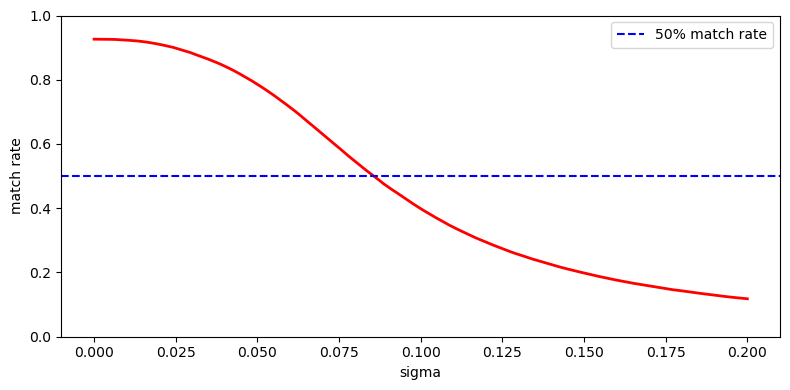

In [7]:
sigmas = np.linspace(0,.2,150)
results = {}
for sigma in sigmas:
    rng = np.random.default_rng(seed=10404)
    mat, mix = cl(100)                                   
    d = dialect_matrices(mat, 30, sigma=sigma)
    common_vectors, perturbed_vectors = vector_sampling(mat, d)
    common_tokens, perturbed_tokens = tokenize_vectors(common_vectors, perturbed_vectors, n_bins=1000)
    match_rate = (common_tokens == perturbed_tokens).mean()
    results[sigma] = match_rate
    print(f"sigma={sigma:.3f}, match rate = {match_rate:.3f}")

sigmas_list = list(results.keys())
match_rates = [results[s] for s in sigmas_list]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sigmas_list, match_rates, color="red", linewidth=2)
ax.axhline(.5, color="blue", linestyle="--", label="50% match rate")
ax.set_xlabel("sigma")
ax.set_ylabel("match rate")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()


mu=0.000, sigma=0.000, match_rate=1.000
mu=0.000, sigma=0.001, match_rate=1.000
mu=0.000, sigma=0.003, match_rate=1.000
mu=0.000, sigma=0.004, match_rate=0.999
mu=0.000, sigma=0.005, match_rate=0.997
mu=0.000, sigma=0.007, match_rate=0.997
mu=0.000, sigma=0.008, match_rate=0.995
mu=0.000, sigma=0.009, match_rate=0.993
mu=0.000, sigma=0.011, match_rate=0.991
mu=0.000, sigma=0.012, match_rate=0.988
mu=0.000, sigma=0.013, match_rate=0.986
mu=0.000, sigma=0.015, match_rate=0.983
mu=0.000, sigma=0.016, match_rate=0.979
mu=0.000, sigma=0.017, match_rate=0.975
mu=0.000, sigma=0.019, match_rate=0.972
mu=0.000, sigma=0.020, match_rate=0.967
mu=0.000, sigma=0.021, match_rate=0.963
mu=0.000, sigma=0.023, match_rate=0.959
mu=0.000, sigma=0.024, match_rate=0.952
mu=0.000, sigma=0.026, match_rate=0.946
mu=0.000, sigma=0.027, match_rate=0.943
mu=0.000, sigma=0.028, match_rate=0.936
mu=0.000, sigma=0.030, match_rate=0.930
mu=0.000, sigma=0.031, match_rate=0.923
mu=0.000, sigma=0.032, match_rate=0.919


/var/folders/m_/clvqh96x4nj3lzfkfbbf_4gc0000gn/T/ipykernel_65741/3184206692.py:18: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(heatmap, origin = "lower", aspect="auto", extent=[
/var/folders/m_/clvqh96x4nj3lzfkfbbf_4gc0000gn/T/ipykernel_65741/3184206692.py:18: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(heatmap, origin = "lower", aspect="auto", extent=[


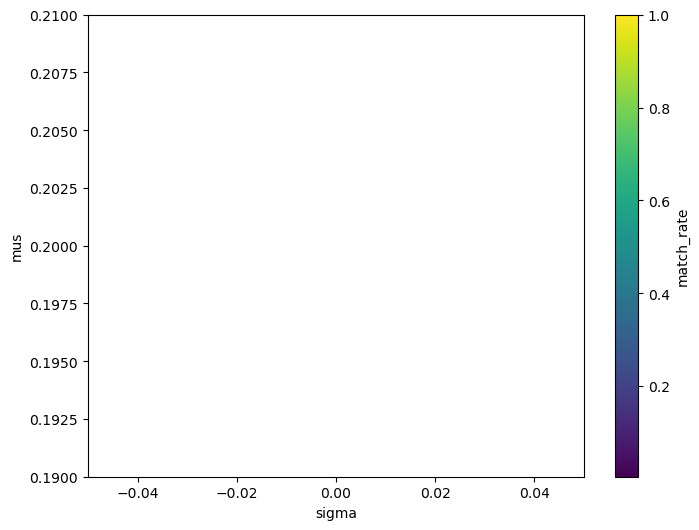

In [161]:
mu_scale = np.linspace(0,.2,150)
heatmap = np.zeros((len(mu_scale),len(sigmas)))
rng = np.random.default_rng(10404)
for i, mu in enumerate(mu_scale):
    for j, sigma in enumerate(sigmas):
        mat, mix = cl(200)
        d = dialect_matrices(mat, 30, sigma=sigma,mu_scale=mu)
        common_vectors,perturbed_vectors = vector_sampling(mat,d)
        common_tokens, perturbed_tokens = tokenize_vectors(common_vectors,perturbed_vectors,n_bins = 1000)
        match_rate = (common_tokens == perturbed_tokens).mean()
        heatmap[i,j]= match_rate
        print(
            f"mu={mu:.3f}, "
            f"sigma={sigma:.3f}, "
            f"match_rate={match_rate:.3f}"
        )
plt.figure(figsize=(8,6))
plt.imshow(heatmap, origin = "lower", aspect="auto", extent=[
    min(sigmas),
    min(mu_scale),
    max(sigmas),
    max(mu_scale)
])
plt.xlabel("sigma")
plt.ylabel("mus")
plt.colorbar(label = "match_rate")

    


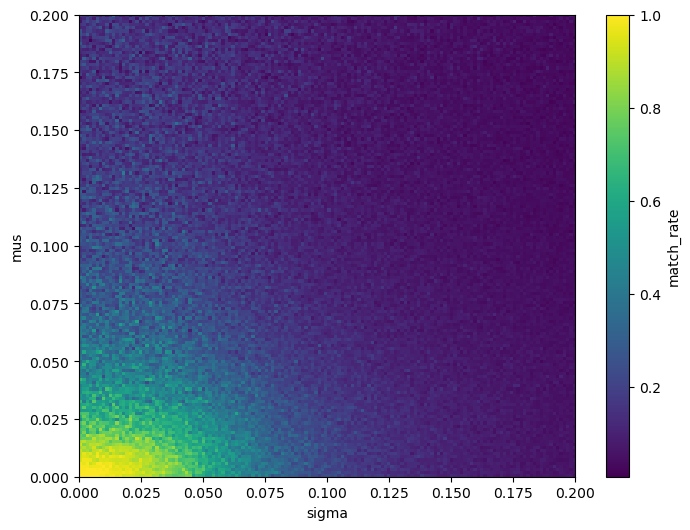

In [47]:
plt.figure(figsize=(8,6))
plt.imshow(heatmap, origin = "lower", aspect="auto", extent=[
    min(sigmas),   
    max(sigmas),   
    min(mu_scale),  
    max(mu_scale) 
])
plt.xlabel("sigma"
plt.ylabel("mus")
plt.colorbar(label = "match_rate")
plt.show()

In [134]:
def pca_tokenizer(common_vectors, perturbed_vectors, n_comp =10 , n_bins = 1000):
    pca = PCA(n_components=n_comp)
    pca.fit(common_vectors)
    common_proj = pca.transform(common_vectors)
    perturb_proj = pca.transform(perturbed_vectors)
    common_tokens_pca = np.zeros((len(common_vectors),n_comp), dtype=int)
    perturb_tokens_pca = np.zeros((len(perturbed_vectors),n_comp),dtype = int)
    for i in range(n_comp):
        lo = min(common_proj[:,i].min(), perturb_proj[:,i].min())
        hi = max(common_proj[:,i].max(), perturb_proj[:,i].max())
        bins = np.linspace(lo,hi,n_bins+1)
        common_tokens_pca[:,i ]= np.digitize(common_proj[:,i],bins)
        perturb_tokens_pca[:,i]=np.digitize(perturb_proj[:,i],bins)
    return common_tokens_pca, perturb_tokens_pca

def pca_match_rate(common_tokens ,perturbed_tokens): 
    exact_match = np.all(common_tokens == perturbed_tokens, axis=1)
    
    component_match = (common_tokens == perturbed_tokens).mean(axis=0)
    mean_component_match = component_match.mean()
    return exact_match.mean(), mean_component_match, component_match
common_tokens_pca, perturb_tokens_pca = pca_tokenizer(common_vectors, perturbed_vectors)


In [136]:
overall, mean_comp_rate, comp_rate = pca_match_rate(common_tokens_pca, perturb_tokens_pca)
print(f"mean component match rate : {mean_comp_rate: .3f}")

mean component match rate :  0.017


974.757


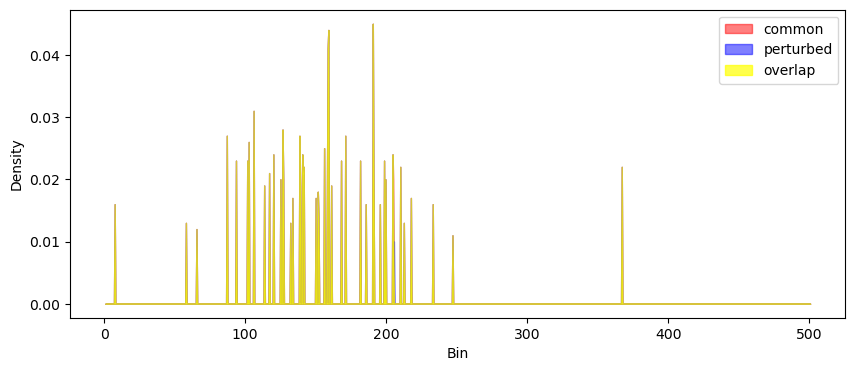

In [26]:
def token(common_vectors,perturbed_vectors, n_bins = 1000):
    projections_common = common_vectors @ perturbed_vectors.T
    projections_dialect = perturbed_vectors @ perturbed_vectors.T
    lo = min(projections_common.min(),projections_dialect.min())
    hi = max(projections_common.max(),projections_dialect.max())
    bins = np.linspace(lo,hi, n_bins+1)
    common_tokens = np.digitize(projections_common,bins)
    dialect_tokens = np.digitize(projections_dialect,bins)
    return common_tokens, dialect_tokens
ctoken, ptoken = token(common_vectors,perturbed_vectors)
m = np.sum(ctoken == ptoken)
mr = m/len(ctoken)
print(mr)
def bin_distribution(common_tokens,perturbed_tokens, n_bins = 1000):
    overlaps = []
    for d in range(ptoken.shape[0]):
        common_hist, _ = np.histogram(ctoken[:,d], bins = n_bins , range = (1,n_bins))
        perturb_hist, _ = np.histogram(ptoken[:,d], bins = n_bins,range = (1,n_bins))
        common_hist = common_hist/ common_hist.sum()
        perturb_hist = perturb_hist/perturb_hist.sum()
        overlap = np.minimum(common_hist, perturb_hist).sum()
        overlaps.append(overlap)
    return common_hist, perturb_hist

common_hist, perturb_hist = bin_distribution(common_tokens,perturbed_tokens)
n_bins = 1000
edges = np.linspace(1,n_bins+1, len(common_hist)+1)
bin_centers = (edges[:-1]+edges[:1])/2
fig,ax = plt.subplots(figsize = (10,4))
ax.fill_between(bin_centers,common_hist, alpha = .5, color = "red", label = "common")
ax.fill_between(bin_centers,perturb_hist,alpha = .5, color = "blue", label = "perturbed"  )
ax.fill_between(bin_centers, np.minimum(common_hist,perturb_hist), alpha = .7, color = "yellow",label = "overlap")
ax.set_xlabel("Bin")
ax.set_ylabel("Density")

ax.legend()
plt.show()

In [ ]:
def sigma_shift_rate(dialect_sigma, n_dialect=30, n_samples=1000,
                     n_bins=1000, seed=10404, target=0.847):
    global rng
    rng = np.random.default_rng(seed=seed)

    mat, mix = cl(50)
    d = dialect_matrices(mat, n_dialect, sigma=dialect_sigma)
    common_vectors, perturbed_vectors = vector_sampling(mat, d, n_samples=n_samples)
    c_tok, p_tok = tokenize_vectors(common_vectors, perturbed_vectors, n_bins=n_bins)

    rate = (c_tok == p_tok).mean()
    return rate - target
sigma_star = brentq(sigma_shift_rate, a = 0, b = .5, xtol = 1e-5)
print(sigma_star)